# PDE-Constrained QAOA: Depth Sweep Experiments

Comparing **Expected Approximation Ratios** and **Feasibility Probabilities** across QAOA depths P=1,2,3,4,5 for three models:
1. Penalty QUBO with tight λ (computed bound)
2. Penalty QUBO with naive λ = 10⁸
3. XY Mixer QAOA (Ring topology)

In [1]:
import qiskit
import qiskit_algorithms
import qiskit_optimization

from qiskit_aer import AerSimulator
from qiskit.primitives import Sampler
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

from qiskit_algorithms import QAOA, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA

from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.problems import QuadraticProgram

import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import time

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

print("qiskit version:", qiskit.__version__)
print("qiskit algorithms version:", qiskit_algorithms.__version__)
print("qiskit optimization version:", qiskit_optimization.__version__)

qiskit version: 1.3.2
qiskit algorithms version: 0.3.1
qiskit optimization version: 0.6.1


## Data Loading & PDE QUBO Setup

In [2]:
# Load MATLAB file
data = scipy.io.loadmat('ifiss3.6/QUBO_4.mat')

Phi = np.array(data['Phi'])
M = np.array(data['M'].toarray())
Kinv = np.array(data['Kinv'])
yhat_vec = np.array(data['yhat_vec']).squeeze()

s = 4  # Hamming weight upper bound

print('Phi shape:', Phi.shape)
print('M shape:', M.shape)
print('Kinv shape:', Kinv.shape)
print('yhat_vec shape:', yhat_vec.shape)

Phi shape: (289, 16)
M shape: (289, 289)
Kinv shape: (289, 289)
yhat_vec shape: (289,)


In [3]:
def generate_pde_qubo(M, Kinv, Phi, yd):
    Q = np.array((1/2) * (Phi.T @ M @ Kinv @ M @ Kinv @ M @ Phi))
    q = np.array((1/2) * (-1*(yd.T @ M @ Kinv @ M @ Phi).T - (Phi.T @ M @ Kinv.T @ M @ yd)))
    c = np.array((1/2) * yd.T @ M @ yd)
    return Q, q, c

Q, q, c = generate_pde_qubo(M, Kinv, Phi, yhat_vec)
n_original = q.shape[0]

print(f'Q shape: {Q.shape}, q shape: {q.shape}, c: {float(c):.6f}')
print(f'Number of original decision variables: {n_original}')

Q shape: (16, 16), q shape: (16,), c: 5.688283
Number of original decision variables: 16


## Problem Setup: Three QAOA Models

In [4]:
from scipy.optimize import minimize as scipy_minimize

def compute_lambda(Q, q, c, s):
    """Compute a practical bound on the penalty parameter \u03bb for QUBO."""
    n = q.shape[0]
    def objective(u):
        return u @ Q @ u + q @ u + c
    bounds = [(0, 1)] * n
    u0 = np.zeros(n)
    result = scipy_minimize(objective, u0, bounds=bounds, method="SLSQP")
    if not result.success:
        raise RuntimeError("Relaxed problem did not converge")
    lb = result.fun
    top_s_indices = np.argsort(-result.x)[:s]
    u_feasible = np.zeros(n)
    u_feasible[top_s_indices] = 1
    ub = u_feasible @ Q @ u_feasible + q @ u_feasible + c
    lam = ub - lb
    return lam

lam_tight = compute_lambda(Q, q, c, s)
lam_naive = 1e8

print(f"Tight penalty \u03bb: {lam_tight:.4f}")
print(f"Naive penalty \u03bb: {lam_naive:.2e}")

Tight penalty λ: 36.6451
Naive penalty λ: 1.00e+08


In [5]:
def build_penalty_qubo(Q, q, c, s, lam, name="Penalty QUBO"):
    """Build penalty QUBO with binary expansion slack variables."""
    n = q.shape[0]
    log_s = int(np.ceil(np.log2(s + 1)))
    total_vars = n + log_s

    padded_Q = np.zeros((total_vars, total_vars))
    padded_Q[:n, :n] = Q
    padded_q = np.zeros(total_vars)
    padded_q[:n] = q

    e = np.ones(n)
    a = np.array([2**j for j in range(log_s)])
    t = np.concatenate([e, a])

    hat_Q = np.outer(t, t)
    hat_q = -2 * s * t
    penalty_const = s**2

    Q_total = padded_Q + lam * hat_Q
    q_total = padded_q + lam * hat_q
    c_total = c + lam * penalty_const

    qubo = QuadraticProgram(name)
    for i in range(total_vars):
        qubo.binary_var(name=f"x{i}")
    qubo.minimize(constant=float(c_total), linear=q_total, quadratic=Q_total)
    return qubo

qubo_tight = build_penalty_qubo(Q, q, c, s, lam_tight, "Tight Penalty QUBO")
qubo_naive = build_penalty_qubo(Q, q, c, s, lam_naive, "Naive Penalty QUBO")

print(f"Tight Penalty QUBO: {qubo_tight.get_num_vars()} variables")
print(f"Naive Penalty QUBO: {qubo_naive.get_num_vars()} variables")

Tight Penalty QUBO: 19 variables
Naive Penalty QUBO: 19 variables


In [6]:
def build_bqo(Q, q, c, s):
    """Build the original BQO with Hamming weight constraint."""
    n = q.shape[0]
    total_vars = n + s
    padded_Q = np.zeros((total_vars, total_vars))
    padded_Q[:n, :n] = Q
    padded_q = np.zeros(total_vars)
    padded_q[:n] = q

    bqo = QuadraticProgram("PDE constrained BQO")
    for i in range(total_vars):
        bqo.binary_var(name=f"x{i}")
    bqo.linear_constraint(
        linear={f"x{i}": 1 for i in range(total_vars)},
        sense="<=", rhs=s, name="hamming_weight"
    )
    bqo.minimize(constant=float(c), linear=padded_q, quadratic=padded_Q)
    return bqo

bqo = build_bqo(Q, q, c, s)
prob_size = n_original + s
print(f"BQO: {bqo.get_num_vars()} variables ({prob_size} qubits)")

BQO: 20 variables (20 qubits)


In [7]:
# Classical exact solver for optimal value
np_solver = NumPyMinimumEigensolver()
np_opt = MinimumEigenOptimizer(np_solver)

classical_result = np_opt.solve(bqo)
optimal_value = classical_result.fval

print(f"Optimal value: {optimal_value:.6f}")
print(f"Optimal solution: {[int(x) for x in classical_result.x]}")
print(f"Hamming weight: {int(sum(classical_result.x))}")

Optimal value: 0.551790
Optimal solution: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0]
Hamming weight: 3


In [ ]:
# Remove constraint for XY mixer QAOA (constraint enforced by mixer instead)
bqo.remove_linear_constraint("hamming_weight")

# Initial state: first s qubits set to |1\u27e9
init_qc = QuantumCircuit(prob_size)
for idx in range(s):
    init_qc.x(idx)

# Ring XY Mixer
beta = Parameter("\u03b2")
ring_xy_mixer = QuantumCircuit(prob_size, name="Ring XY Mixer")
for idx in range(prob_size):
    idy = (idx + 1) % prob_size
    ring_xy_mixer.rxx(2 * beta, idx, idy)
    ring_xy_mixer.ryy(2 * beta, idx, idy)
    ring_xy_mixer.barrier()

print(f"XY Mixer setup complete ({prob_size} qubits)")
print(f"Initial state Hamming weight: {s}")

XY Mixer setup complete (20 qubits)
Initial state Hamming weight: 4


## Depth Sweep Experiments (Noiseless)

In [9]:
def run_depth_sweep(model, depths, optimal_value, n_original, s,
                    model_name="", initial_state=None, mixer=None):
    """
    Run noiseless QAOA at each depth and compute:
      - Expected approximation ratio: sum_i p_i * (optimal / f_i)
      - Feasibility probability: sum_i p_i * I(sum(x_i[:n]) <= s)
    """
    expected_ars = []
    feas_probs = []

    for p in depths:
        t0 = time.time()

        # Setup noiseless QAOA
        backend = AerSimulator()
        sampler = Sampler()
        sampler.set_options(shots=1024, backend=backend)

        qaoa_kwargs = dict(
            sampler=sampler,
            optimizer=COBYLA(),
            reps=p,
            initial_point=np.zeros(2 * p),
            aggregation=1.0
        )
        if initial_state is not None:
            qaoa_kwargs['initial_state'] = initial_state
        if mixer is not None:
            qaoa_kwargs['mixer'] = mixer

        qaoa = QAOA(**qaoa_kwargs)
        qaoa_opt = MinimumEigenOptimizer(qaoa)
        result = qaoa_opt.solve(model)
        samples = result.samples

        # Re-evaluate fvals on model objective
        for samp in samples:
            samp.fval = model.objective.evaluate(samp.x)

        # Expected approximation ratio
        exp_ar = sum(
            samp.probability * (optimal_value / samp.fval)
            for samp in samples
            if samp.fval > 0
        )

        # Feasibility probability: original Hamming weight constraint
        feas_prob = sum(
            samp.probability
            for samp in samples
            if sum(samp.x[:n_original]) <= s
        )

        expected_ars.append(exp_ar)
        feas_probs.append(feas_prob)

        elapsed = time.time() - t0
        print(f"  [{model_name}] P={p}: E[AR]={exp_ar:.4f}, Feas={feas_prob:.4f} ({elapsed:.1f}s)")

    return expected_ars, feas_probs

depths = [1, 2, 3, 4, 5]

In [10]:
print("=" * 60)
print(f"Model 1: Penalty QUBO with Tight \u03bb = {lam_tight:.4f}")
print("=" * 60)
ar_tight, feas_tight = run_depth_sweep(
    qubo_tight, depths, optimal_value, n_original, s,
    model_name="Tight Penalty"
)

Model 1: Penalty QUBO with Tight λ = 36.6451
  [Tight Penalty] P=1: E[AR]=0.0009, Feas=0.0547 (126.7s)
  [Tight Penalty] P=2: E[AR]=0.0236, Feas=0.8994 (4395.5s)
  [Tight Penalty] P=3: E[AR]=0.0007, Feas=0.0430 (487.4s)
  [Tight Penalty] P=4: E[AR]=0.0013, Feas=0.0762 (732.6s)
  [Tight Penalty] P=5: E[AR]=0.0105, Feas=0.6660 (995.4s)


In [11]:
print("=" * 60)
print("Model 2: Penalty QUBO with Naive \u03bb = 10\u2078")
print("=" * 60)
ar_naive, feas_naive = run_depth_sweep(
    qubo_naive, depths, optimal_value, n_original, s,
    model_name="Naive Penalty"
)

Model 2: Penalty QUBO with Naive λ = 10⁸
  [Naive Penalty] P=1: E[AR]=0.0002, Feas=0.0371 (151.3s)
  [Naive Penalty] P=2: E[AR]=0.0000, Feas=0.0000 (442.5s)
  [Naive Penalty] P=3: E[AR]=0.0014, Feas=0.2949 (396.2s)
  [Naive Penalty] P=4: E[AR]=0.0023, Feas=0.1982 (659.4s)
  [Naive Penalty] P=5: E[AR]=0.0024, Feas=0.2002 (813.5s)


In [12]:
print("=" * 60)
print("Model 3: XY Mixer QAOA (Ring)")
print("=" * 60)
ar_xy, feas_xy = run_depth_sweep(
    bqo, depths, optimal_value, n_original, s,
    model_name="XY Mixer",
    initial_state=init_qc,
    mixer=ring_xy_mixer
)

Model 3: XY Mixer QAOA (Ring)
  [XY Mixer] P=1: E[AR]=0.0431, Feas=1.0000 (36.5s)
  [XY Mixer] P=2: E[AR]=0.1524, Feas=1.0000 (120.6s)
  [XY Mixer] P=3: E[AR]=0.5125, Feas=1.0000 (278.4s)
  [XY Mixer] P=4: E[AR]=0.5183, Feas=1.0000 (419.4s)
  [XY Mixer] P=5: E[AR]=0.4108, Feas=1.0000 (1100.2s)


## Results

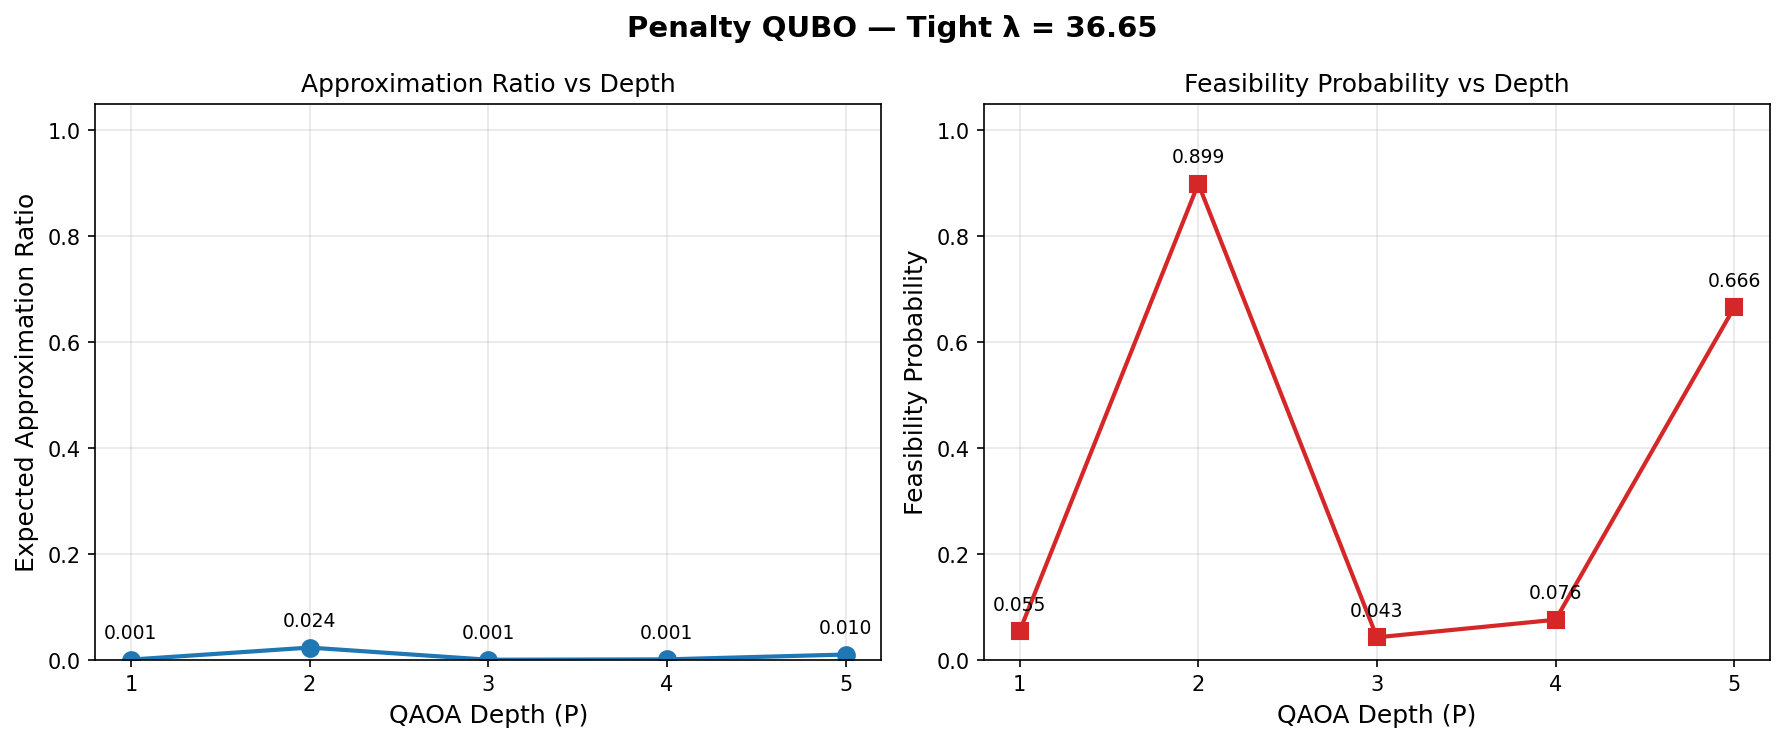

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
fig.suptitle(f"Penalty QUBO \u2014 Tight \u03bb = {lam_tight:.2f}", fontsize=14, fontweight='bold')

# Approximation Ratio
ax1.plot(depths, ar_tight, 'o-', color='tab:blue', linewidth=2, markersize=8)
for i, v in enumerate(ar_tight):
    ax1.annotate(f'{v:.3f}', (depths[i], v), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=9)
ax1.set_xlabel("QAOA Depth (P)", fontsize=12)
ax1.set_ylabel("Expected Approximation Ratio", fontsize=12)
ax1.set_title("Approximation Ratio vs Depth")
ax1.set_xticks(depths)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# Feasibility
ax2.plot(depths, feas_tight, 's-', color='tab:red', linewidth=2, markersize=8)
for i, v in enumerate(feas_tight):
    ax2.annotate(f'{v:.3f}', (depths[i], v), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=9)
ax2.set_xlabel("QAOA Depth (P)", fontsize=12)
ax2.set_ylabel("Feasibility Probability", fontsize=12)
ax2.set_title("Feasibility Probability vs Depth")
ax2.set_xticks(depths)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tight_penalty_depth_sweep.png", bbox_inches='tight')
plt.show()

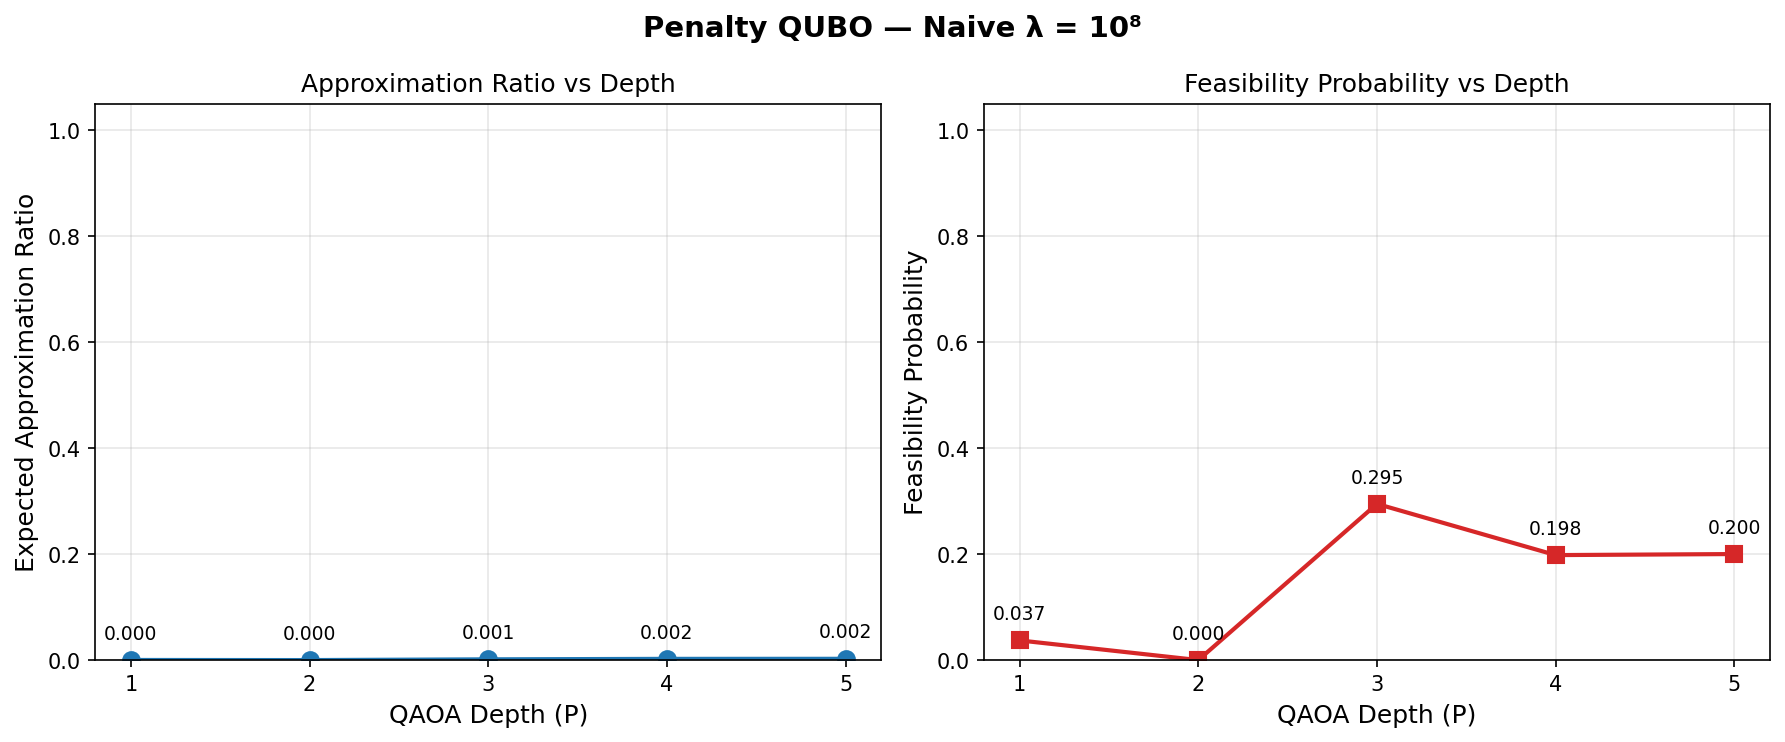

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
fig.suptitle("Penalty QUBO \u2014 Naive \u03bb = 10\u2078", fontsize=14, fontweight='bold')

# Approximation Ratio
ax1.plot(depths, ar_naive, 'o-', color='tab:blue', linewidth=2, markersize=8)
for i, v in enumerate(ar_naive):
    ax1.annotate(f'{v:.3f}', (depths[i], v), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=9)
ax1.set_xlabel("QAOA Depth (P)", fontsize=12)
ax1.set_ylabel("Expected Approximation Ratio", fontsize=12)
ax1.set_title("Approximation Ratio vs Depth")
ax1.set_xticks(depths)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# Feasibility
ax2.plot(depths, feas_naive, 's-', color='tab:red', linewidth=2, markersize=8)
for i, v in enumerate(feas_naive):
    ax2.annotate(f'{v:.3f}', (depths[i], v), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=9)
ax2.set_xlabel("QAOA Depth (P)", fontsize=12)
ax2.set_ylabel("Feasibility Probability", fontsize=12)
ax2.set_title("Feasibility Probability vs Depth")
ax2.set_xticks(depths)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("naive_penalty_depth_sweep.png", bbox_inches='tight')
plt.show()

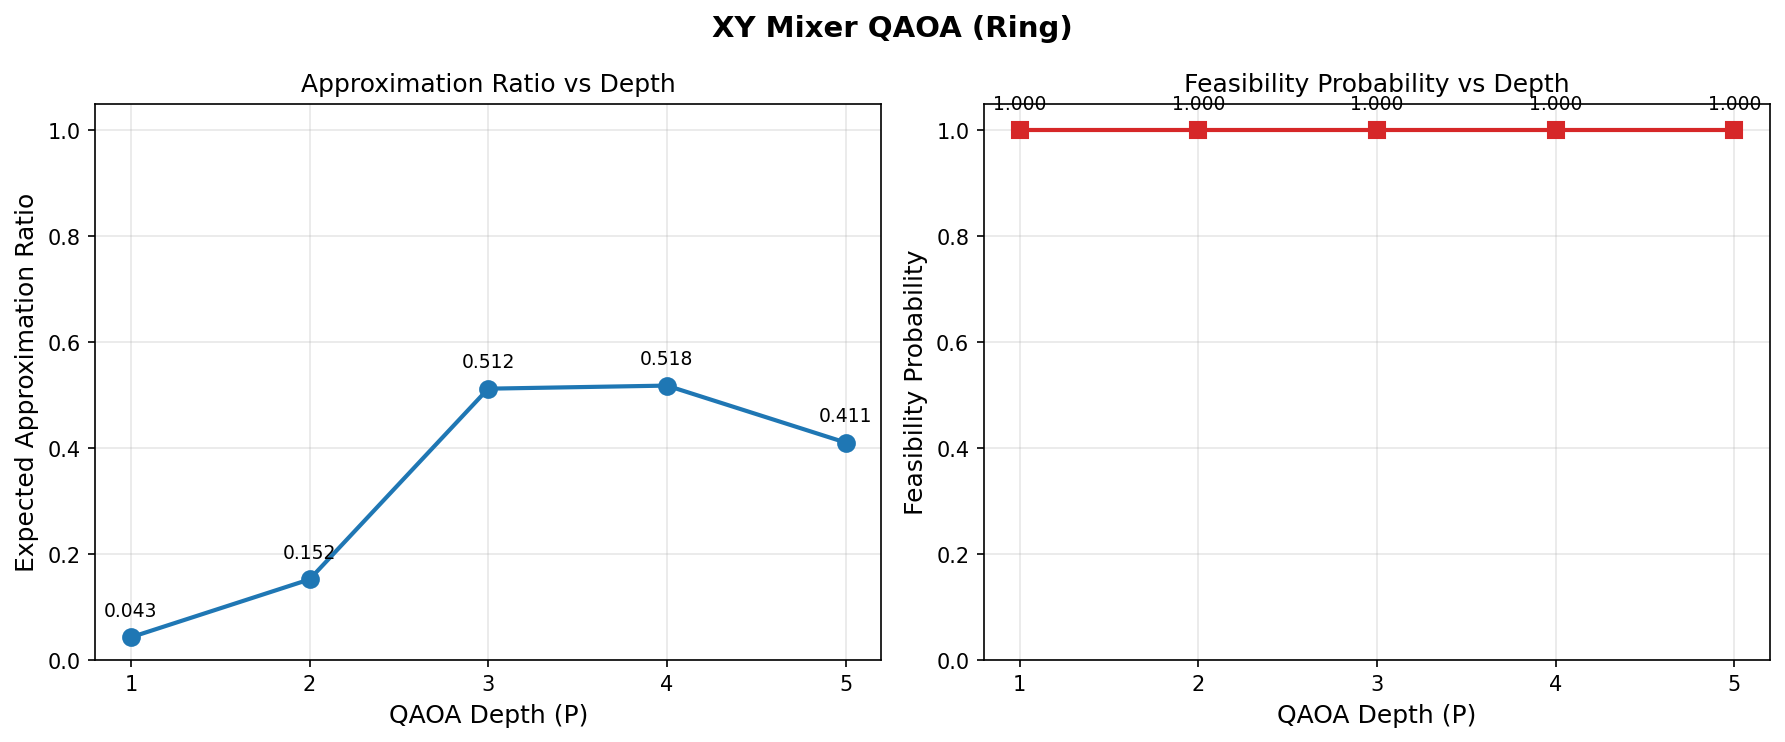

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
fig.suptitle("XY Mixer QAOA (Ring)", fontsize=14, fontweight='bold')

# Approximation Ratio
ax1.plot(depths, ar_xy, 'o-', color='tab:blue', linewidth=2, markersize=8)
for i, v in enumerate(ar_xy):
    ax1.annotate(f'{v:.3f}', (depths[i], v), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=9)
ax1.set_xlabel("QAOA Depth (P)", fontsize=12)
ax1.set_ylabel("Expected Approximation Ratio", fontsize=12)
ax1.set_title("Approximation Ratio vs Depth")
ax1.set_xticks(depths)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# Feasibility
ax2.plot(depths, feas_xy, 's-', color='tab:red', linewidth=2, markersize=8)
for i, v in enumerate(feas_xy):
    ax2.annotate(f'{v:.3f}', (depths[i], v), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=9)
ax2.set_xlabel("QAOA Depth (P)", fontsize=12)
ax2.set_ylabel("Feasibility Probability", fontsize=12)
ax2.set_title("Feasibility Probability vs Depth")
ax2.set_xticks(depths)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("xy_mixer_depth_sweep.png", bbox_inches='tight')
plt.show()

In [17]:
print("\n" + "=" * 75)
print("SUMMARY")
print("=" * 75)
print(f"Optimal value: {optimal_value:.6f}")
print(f"Tight penalty \u03bb: {lam_tight:.4f}")
print()
header = f"{'P':<4} | {'Tight Penalty':^20} | {'Naive Penalty (10⁸)':^20} | {'XY Mixer (Ring)':^20}"
sub    = f"{'':4} | {'E[AR]':>9} {'Feas':>9} | {'E[AR]':>9} {'Feas':>9} | {'E[AR]':>9} {'Feas':>9}"
print(header)
print(sub)
print("-" * 75)
for i, p in enumerate(depths):
    print(f"{p:<4} | {ar_tight[i]:>9.4f} {feas_tight[i]:>9.4f} | "
          f"{ar_naive[i]:>9.4f} {feas_naive[i]:>9.4f} | "
          f"{ar_xy[i]:>9.4f} {feas_xy[i]:>9.4f}")


SUMMARY
Optimal value: 0.551790
Tight penalty λ: 36.6451

P    |    Tight Penalty     | Naive Penalty (10⁸)  |   XY Mixer (Ring)   
     |     E[AR]      Feas |     E[AR]      Feas |     E[AR]      Feas
---------------------------------------------------------------------------
1    |    0.0009    0.0547 |    0.0002    0.0371 |    0.0431    1.0000
2    |    0.0236    0.8994 |    0.0000    0.0000 |    0.1524    1.0000
3    |    0.0007    0.0430 |    0.0014    0.2949 |    0.5125    1.0000
4    |    0.0013    0.0762 |    0.0023    0.1982 |    0.5183    1.0000
5    |    0.0105    0.6660 |    0.0024    0.2002 |    0.4108    1.0000



RESOURCE ESTIMATION (Gate Counts & Depth)

Resource Estimation for Tight Penalty
Depth  | Total Gates  | Depth  | 2-Qubit Gates 
----------------------------------------------
1      | 551          | 107    | 342           
2      | 1083         | 165    | 684           
3      | 1615         | 223    | 1026          
4      | 2147         | 281    | 1368          
5      | 2679         | 339    | 1710          

Resource Estimation for Naive Penalty
Depth  | Total Gates  | Depth  | 2-Qubit Gates 
----------------------------------------------
1      | 551          | 107    | 342           
2      | 1083         | 165    | 684           
3      | 1615         | 223    | 1026          
4      | 2147         | 281    | 1368          
5      | 2679         | 339    | 1710          

Resource Estimation for XY Mixer
Depth  | Total Gates  | Depth  | 2-Qubit Gates 
----------------------------------------------
1      | 556          | 183    | 280           
2      | 1112         | 366    |

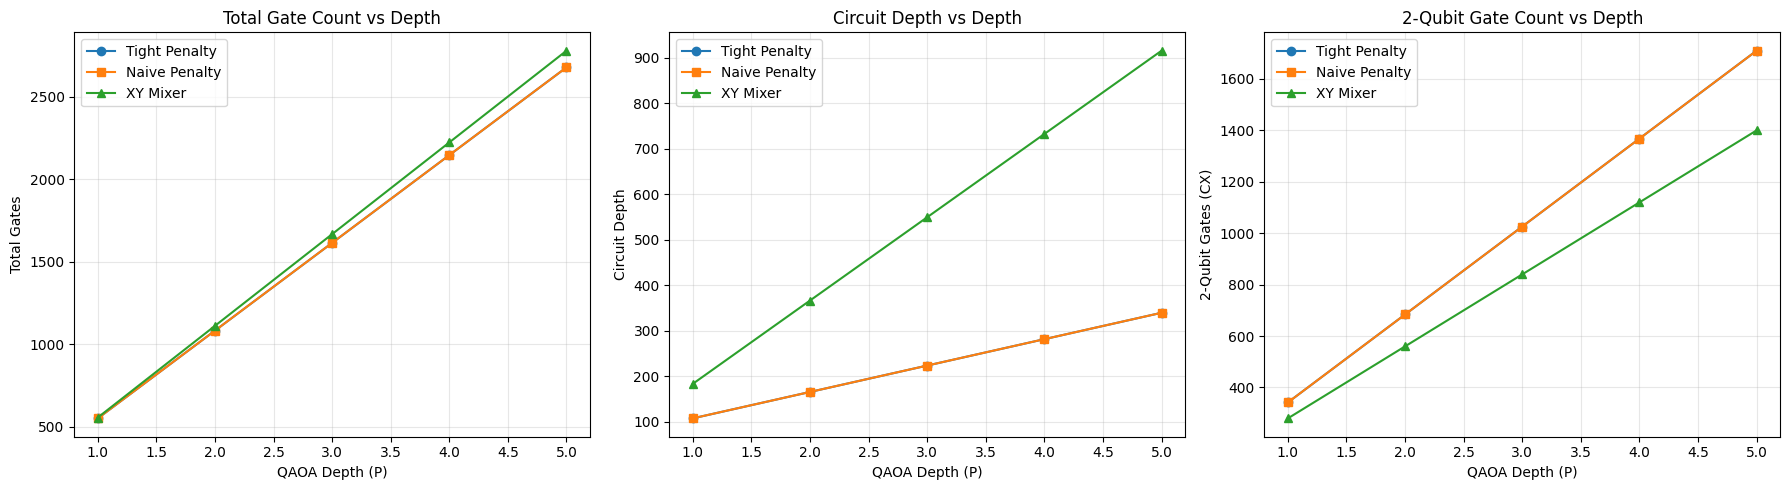

In [23]:
def estimate_resources(model, depths, model_name, initial_state=None, mixer=None):
    from qiskit.circuit.library import QAOAAnsatz
    print(f"\nResource Estimation for {model_name}")
    print(f"{'Depth':<6} | {'Total Gates':<12} | {'Depth':<6} | {'2-Qubit Gates':<14}")
    print("-" * 46)
    
    # Convert model to operator once
    operator, offset = model.to_ising()

    total_gates_list = []
    depth_list = []
    num_2q_list = []

    for p in depths:
        # Construct QAOA Ansatz directly
        # We use QAOAAnsatz from circuit library instead of the algorithm class
        # to directly inspect the circuit structure.
        ansatz = QAOAAnsatz(cost_operator=operator, reps=p, initial_state=initial_state, mixer_operator=mixer)
        
        # QAOA expects 2*p parameters (betas and gammas)
        # We assign dummy parameters to make the circuit concrete for transpilation
        params = [0.1] * ansatz.num_parameters
        qc = ansatz.assign_parameters(params)
        
        # Transpile to basis gates to count 2-qubit gates (CX)
        # optimization_level=1 does basic mapping and decomposition
        transpiled_qc = qiskit.transpile(qc, basis_gates=['u', 'cx'], optimization_level=3)
        
        ops = transpiled_qc.count_ops()
        total_gates = sum(ops.values())
        depth_val = transpiled_qc.depth()
        num_2q = ops.get('cx', 0)
        
        total_gates_list.append(total_gates)
        depth_list.append(depth_val)
        num_2q_list.append(num_2q)
        
        print(f"{p:<6} | {total_gates:<12} | {depth_val:<6} | {num_2q:<14}")
        
    return total_gates_list, depth_list, num_2q_list

print("\n" + "="*60)
print("RESOURCE ESTIMATION (Gate Counts & Depth)")
print("="*60)

# 1. Tight Penalty
res_tight = estimate_resources(qubo_tight, depths, "Tight Penalty")

# 2. Naive Penalty
res_naive = estimate_resources(qubo_naive, depths, "Naive Penalty")

# 3. XY Mixer
res_xy = estimate_resources(bqo, depths, "XY Mixer", initial_state=init_qc, mixer=ring_xy_mixer)

# --- Plotting ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Total Gates
ax1.plot(depths, res_tight[0], 'o-', label='Tight Penalty')
ax1.plot(depths, res_naive[0], 's-', label='Naive Penalty')
ax1.plot(depths, res_xy[0], '^-', label='XY Mixer')
ax1.set_xlabel('QAOA Depth (P)')
ax1.set_ylabel('Total Gates')
ax1.set_title('Total Gate Count vs Depth')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Circuit Depth
ax2.plot(depths, res_tight[1], 'o-', label='Tight Penalty')
ax2.plot(depths, res_naive[1], 's-', label='Naive Penalty')
ax2.plot(depths, res_xy[1], '^-', label='XY Mixer')
ax2.set_xlabel('QAOA Depth (P)')
ax2.set_ylabel('Circuit Depth')
ax2.set_title('Circuit Depth vs Depth')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 2-Qubit Gates
ax3.plot(depths, res_tight[2], 'o-', label='Tight Penalty')
ax3.plot(depths, res_naive[2], 's-', label='Naive Penalty')
ax3.plot(depths, res_xy[2], '^-', label='XY Mixer')
ax3.set_xlabel('QAOA Depth (P)')
ax3.set_ylabel('2-Qubit Gates (CX)')
ax3.set_title('2-Qubit Gate Count vs Depth')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.savefig('resource_estimation.png')
plt.show()